In [9]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [10]:
pn = '../data/runs.csv'
df = pd.read_csv(pn)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   checkpoint         27 non-null     str    
 1   attn_mode          27 non-null     str    
 2   metal_filter       26 non-null     str    
 3   num_hypotheses     27 non-null     int64  
 4   diversity_weight   15 non-null     float64
 5   learn_temperature  26 non-null     object 
 6   use_plm            26 non-null     object 
 7   batch_size         26 non-null     float64
 8   num_epochs         26 non-null     float64
 9   lr                 26 non-null     float64
 10  grad_clip          26 non-null     float64
 11  k                  26 non-null     float64
 12  train_size         26 non-null     float64
 13  val_size           26 non-null     float64
 14  best_epoch         26 non-null     float64
 15  best_train_loss    26 non-null     float64
 16  best_val_rmse      26 non-null     floa

In [11]:
df

,checkpoint,attn_mode,metal_filter,num_hypotheses,diversity_weight,learn_temperature,use_plm,batch_size,num_epochs,lr,...,best_train_loss,best_val_rmse,test_size,test_rmse,test_mean,test_median,test_pct_2a,test_pct_5a,last_updated,relative_coords
0,best_model_v9_zn_topk_wta3.pt,topk,ZN,3,0.05,True,False,16.0,25.0,0.001,...,75.3283,9.7309,297.0,9.8490,7.4756,6.0261,18.18,45.79,2026-03-31 10:43,NaN
1,best_model_v9_zn_softmax_wta3.pt,softmax,ZN,3,0.05,True,False,16.0,25.0,0.001,...,183.6580,14.1304,297.0,15.3938,13.3079,11.8343,0.00,7.07,2026-03-31 10:42,NaN
2,best_model_v9_zn_softmax.pt,softmax,ZN,1,NaN,True,False,16.0,25.0,0.001,...,27.9541,13.7375,297.0,12.6433,9.2945,5.2119,13.13,46.46,2026-09-15 09:49,NaN
3,test_model.pt,softmax,NaN,1,NaN,True,False,16.0,8.0,0.001,...,80.6198,19.1927,NaN,NaN,NaN,NaN,NaN,NaN,2026-03-30 15:04,NaN
4,best_model_v9_zn_sparsemax.pt,sparsemax,ZN,1,NaN,True,False,16.0,25.0,0.001,...,34.7988,14.9823,297.0,15.5773,12.3017,11.0719,17.17,27.61,2026-03-31 10:42,NaN
5,best_model_v9_zn_sparsemax_wta3.pt,sparsemax,ZN,3,0.05,True,False,16.0,25.0,0.001,...,60.3595,9.2159,297.0,9.3002,6.7243,4.8067,23.57,51.18,2026-03-31 10:43,NaN
6,best_model_v9_zn_topk.pt,topk,ZN,1,NaN,True,False,16.0,25.0,0.001,...,23.3253,12.9932,297.0,12.3848,9.3247,8.5634,28.96,39.73,2026-03-31 10:43,NaN
7,best_model_v9_zn_sparsemax_wta5.pt,sparsemax,ZN,5,0.05,True,False,16.0,25.0,0.001,...,161.9312,19.1912,297.0,21.5740,19.0893,19.6658,0.00,3.70,2026-04-01 07:10,NaN
8,best_model_v9_zn_sparsemax_plm_wta3.pt,sparsemax,ZN,3,0.05,True,True,16.0,25.0,0.001,...,10.4980,6.6268,297.0,4.9986,2.8752,1.2575,65.99,86.53,2026-04-01 10:24,NaN
9,best_model_v9_zn_sparsemax_k32_wta3.pt,sparsemax,ZN,3,0.05,True,False,16.0,25.0,0.001,...,63.2023,8.0458,297.0,10.9843,8.4296,7.9170,24.92,43.43,2026-04-01 07:10,NaN


In [12]:
bm = (df['metal_filter'] == 'ZN') & (df['num_hypotheses'] == 1)
results = df[bm]
results

,checkpoint,attn_mode,metal_filter,num_hypotheses,diversity_weight,learn_temperature,use_plm,batch_size,num_epochs,lr,...,best_train_loss,best_val_rmse,test_size,test_rmse,test_mean,test_median,test_pct_2a,test_pct_5a,last_updated,relative_coords
2,best_model_v9_zn_softmax.pt,softmax,ZN,1,NaN,True,False,16.0,25.0,0.001,...,27.9541,13.7375,297.0,12.6433,9.2945,5.2119,13.13,46.46,2026-09-15 09:49,NaN
4,best_model_v9_zn_sparsemax.pt,sparsemax,ZN,1,NaN,True,False,16.0,25.0,0.001,...,34.7988,14.9823,297.0,15.5773,12.3017,11.0719,17.17,27.61,2026-03-31 10:42,NaN
6,best_model_v9_zn_topk.pt,topk,ZN,1,NaN,True,False,16.0,25.0,0.001,...,23.3253,12.9932,297.0,12.3848,9.3247,8.5634,28.96,39.73,2026-03-31 10:43,NaN
18,best_model_v9_zn_softmax_plm.pt,softmax,ZN,1,NaN,True,True,16.0,25.0,0.001,...,45.6349,12.6133,297.0,7.5510,4.8740,2.5027,33.00,67.34,2026-09-15 10:46,NaN
19,best_model_v9_zn_sparsemax_plm.pt,sparsemax,ZN,1,NaN,True,True,16.0,25.0,0.001,...,33.0458,10.7436,297.0,7.2519,4.5112,1.9040,52.86,68.01,2026-09-15 11:29,NaN
20,best_model_v9_zn_topk_plm.pt,topk,ZN,1,NaN,True,True,16.0,25.0,0.001,...,40.9223,11.3758,297.0,8.4159,4.9852,2.1255,49.49,77.44,2026-09-15 12:07,NaN
25,heuristic_donor_r4_ZN,heuristic,ZN,1,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,297.0,8.5131,3.1749,0.8578,88.22,90.24,2026-09-17 09:21,NaN
26,best_model_v9_zn_topk_rel.pt,topk,ZN,1,NaN,True,False,16.0,25.0,0.001,...,22.6495,12.7773,297.0,11.4351,7.7927,4.9216,21.21,50.17,2026-09-23 09:17,1.0


In [13]:
ablated = (df['use_plm'] == True ) & (df['num_hypotheses'] == 1)
ab_df = df[ablated]
ab_df

,checkpoint,attn_mode,metal_filter,num_hypotheses,diversity_weight,learn_temperature,use_plm,batch_size,num_epochs,lr,...,best_train_loss,best_val_rmse,test_size,test_rmse,test_mean,test_median,test_pct_2a,test_pct_5a,last_updated,relative_coords
18,best_model_v9_zn_softmax_plm.pt,softmax,ZN,1,NaN,True,True,16.0,25.0,0.001,...,45.6349,12.6133,297.0,7.5510,4.8740,2.5027,33.00,67.34,2026-09-15 10:46,NaN
19,best_model_v9_zn_sparsemax_plm.pt,sparsemax,ZN,1,NaN,True,True,16.0,25.0,0.001,...,33.0458,10.7436,297.0,7.2519,4.5112,1.9040,52.86,68.01,2026-09-15 11:29,NaN
20,best_model_v9_zn_topk_plm.pt,topk,ZN,1,NaN,True,True,16.0,25.0,0.001,...,40.9223,11.3758,297.0,8.4159,4.9852,2.1255,49.49,77.44,2026-09-15 12:07,NaN
22,best_model_v9_bm_sparsemax_plm.pt,sparsemax,bare,1,NaN,True,True,16.0,25.0,0.001,...,32.2051,10.9796,986.0,13.2405,8.1542,2.9459,24.44,59.33,2026-09-15 14:27,NaN
23,best_model_v9_bm_topk_plm.pt,topk,bare,1,NaN,True,True,16.0,25.0,0.001,...,31.1100,11.5730,986.0,14.6352,9.2224,3.2554,16.23,62.47,2026-09-15 15:54,NaN
24,best_model_v9_bm_softmax_plm.pt,softmax,bare,1,NaN,True,True,16.0,25.0,0.001,...,58.3650,11.6663,986.0,12.9401,8.1872,3.8404,24.24,61.16,2026-09-15 17:25,NaN


In [14]:
abbrev_label = list(df['checkpoint'])
abbrev_label = [i.split('_') for i in abbrev_label]
abbrev_label = [[j[0] for j in  i] for i in abbrev_label]
abbrev_label = ["".join(i) for i in abbrev_label]
abbrev_label

['bmvztw',
 'bmvzsw',
 'bmvzs',
 'tm',
 'bmvzs',
 'bmvzsw',
 'bmvzt',
 'bmvzsw',
 'bmvzspw',
 'bmvzskw',
 'bmvbswv',
 'bmvzspmw',
 'bmvbsw',
 'bmvbtw',
 'bmvbspmw',
 'bmvbspw',
 'bmvzsew',
 'bmvztpw',
 'bmvzsp',
 'bmvzsp',
 'bmvztp',
 'bmvzspw',
 'bmvbsp',
 'bmvbtp',
 'bmvbsp',
 'hdrZ',
 'bmvztr']

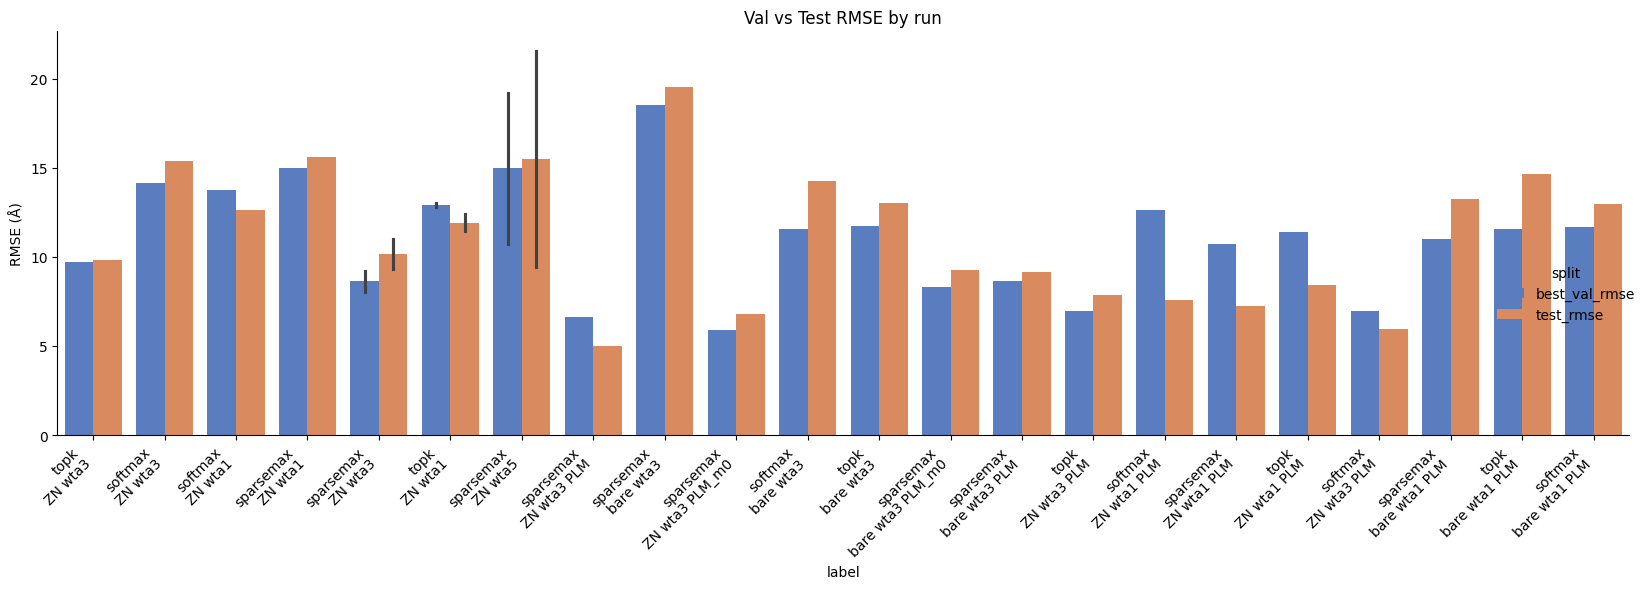

In [15]:
plot_df = df[df['checkpoint'] != 'test_model.pt'].copy()
plot_df['label'] = (
    plot_df['attn_mode'] + '\n'
    + plot_df['metal_filter'].fillna('all') + ' '
    + 'wta' + plot_df['num_hypotheses'].astype(str)
    + plot_df['use_plm'].map({True: ' PLM', False: ''})
    + plot_df['checkpoint'].str.extract(r'(_m0)')[0].fillna('')
)

melted = plot_df.melt(
    id_vars='label',
    value_vars=['best_val_rmse', 'test_rmse'],
    var_name='split', value_name='RMSE (Å)'
)

g = sns.catplot(
    kind='bar',
    data=melted,
    x='label', y='RMSE (Å)',
    hue='split',
    height=6, aspect=2.5,
    palette='muted',
)
g.set_xticklabels(rotation=45, ha='right')
g.set(title='Val vs Test RMSE by run')
plt.tight_layout()
plt.show()


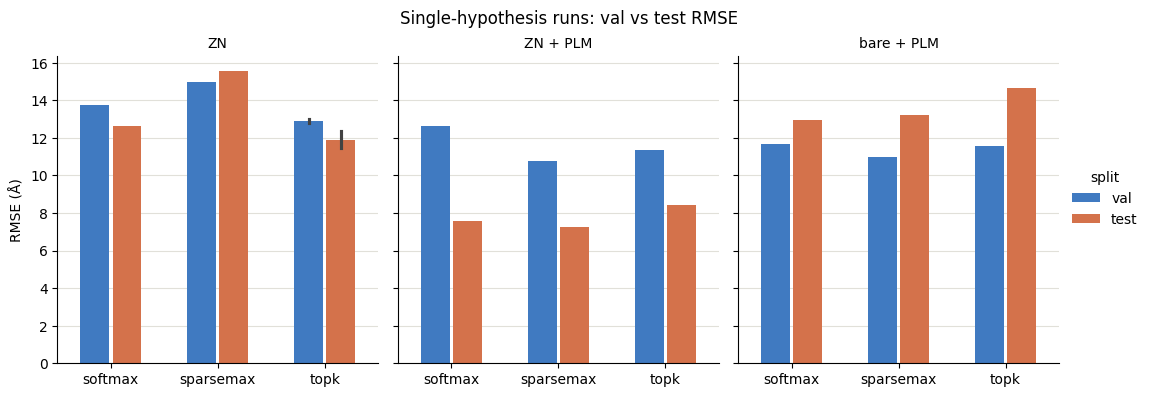

In [16]:
#single-hypothesis
sh = df[(df['num_hypotheses'] == 1) & (df['checkpoint'] != 'test_model.pt')].copy()
sh['subset'] = sh['metal_filter'] + sh['use_plm'].map({True: ' + PLM', False: ''})

melted = sh.melt(
    id_vars=['subset', 'attn_mode'],
    value_vars=['best_val_rmse', 'test_rmse'],
    var_name='split', value_name='RMSE (Å)',
).replace({'split': {'best_val_rmse': 'val', 'test_rmse': 'test'}})

g = sns.catplot(
    kind='bar', data=melted,
    x='attn_mode', y='RMSE (Å)', hue='split',
    col='subset', col_order=['ZN', 'ZN + PLM', 'bare + PLM'],
    order=['softmax', 'sparsemax', 'topk'],
    palette={'val': '#2a78d6', 'test': '#eb6834'},
    width=0.6, gap=0.1, height=4, aspect=0.9,
)
g.set_titles('{col_name}')
g.set_axis_labels('', 'RMSE (Å)')
for ax in g.axes.flat:
    ax.grid(axis='y', color='#e1e0d9')
    ax.set_axisbelow(True)
g.fig.suptitle('Single-hypothesis runs: val vs test RMSE', y=1.03)
plt.show()

3/31/26
Best validation & test RMSE (ZN only)

attention = topk and sparsemax
3 hypotheses

experiments:
1. Graph structure: k k-neighbors = 8, 16, 32
2. num_hypotheses: 3, 5, 7,
3. protein language model


# 4/1/26

Overnight run: 
sparsemax on ZN w/ 
1. 5 hypotheses
2. PLM
3. graph k-neighbors = 32
4. bare metal

observations: 
1. increasing graph density improved val_rmse, lowered test_rmse -> overfitting
    > k-neighbors: 4, 8, 16
2. No improvement on 5 hypotheses; vary diversity_weight?
3. PLM temperature went well above 1.0 on its own; 
4. sparsemax basically couldn't learn at all on bare metal
    > BM on all three attention modes? 



